In [3]:
#Patrones y factores asociados a la consumación de extorsiones registradas por Seguridad 
#Ciudadana en Nezahualcóyotl mediante minería de datos

In [4]:
#Bloque 0. Instalación de librerías
#Ejecuta esto una sola vez
!pip install pandas numpy openpyxl scikit-learn matplotlib mlxtend kmodes

"pip" no se reconoce como un comando interno o externo,
programa o archivo por lotes ejecutable.


In [5]:
import warnings
warnings.filterwarnings("ignore", category=DeprecationWarning)

In [6]:
#Bloque 1. Cargar librerías y archivo
#Fase KDD: Selección de datos
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import re
import unicodedata

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier

from mlxtend.preprocessing import TransactionEncoder
from mlxtend.frequent_patterns import apriori, association_rules

from kmodes.kmodes import KModes


ruta = "Encuesta-Modificada.xlsx"
df = pd.read_excel(ruta)

print("Dimensiones:", df.shape)
print("\nColumnas originales:")
print(df.columns.tolist())

df.head()

Dimensiones: (66, 15)

Columnas originales:
['Marca temporal', 'Carrera', 'Semestre que cursas', '¿Cuál es la Inteligencia Artificial que usas en tu día a día?', 'Edad', '¿Cuál es el uso principal que le das a la Inteligencia Artificial que seleccionaste?', '¿Con qué frecuencia usas IA para tareas escolares?', ' Intento resolver la tarea por mi cuenta antes de usar IA.  ', 'Uso IA cuando no entiendo un tema explicado en clase.  ', 'Cuando realizas trabajos escolares con apoyo de la IA ¿Revisas y modificas lo que genera la IA antes de entregarlo? ', 'Siento que cada vez dependo más de la IA. ', 'Si no tuviera acceso a IA, mi rendimiento bajaría.  ', 'Prefiero usar IA que investigar en libros o artículos. ', 'Considero que podría dejar de usar IA sin problema. ', 'En una escala del 1 al 5, ¿qué tan dependiente te consideras de la IA?\nDonde 1 es nada dependiente y 5 es totalmente dependiente ']


,Marca temporal,Carrera,Semestre que cursas,¿Cuál es la Inteligencia Artificial que usas en tu día a día?,Edad,¿Cuál es el uso principal que le das a la Inteligencia Artificial que seleccionaste?,¿Con qué frecuencia usas IA para tareas escolares?,Intento resolver la tarea por mi cuenta antes de usar IA.,Uso IA cuando no entiendo un tema explicado en clase.,Cuando realizas trabajos escolares con apoyo de la IA ¿Revisas y modificas lo que genera la IA antes de entregarlo?,Siento que cada vez dependo más de la IA.,"Si no tuviera acceso a IA, mi rendimiento bajaría.",Prefiero usar IA que investigar en libros o artículos.,Considero que podría dejar de usar IA sin problema.,"En una escala del 1 al 5, ¿qué tan dependiente te consideras de la IA?\nDonde 1 es nada dependiente y 5 es totalmente dependiente"
0,2026-02-27 21:20:39.590,Ingenieria en Sistemas Inteligentes,6,Chat GPT,Mayor que 20,Uso general,A veces,A veces,A veces,Si,No,No,Si,Si,3.0
1,2026-02-27 21:20:44.168,Ingenieria en Sistemas Inteligentes,6,Chat GPT,Mayor que 20,Uso general,Casi siempre,A veces,A veces,Si,Si,No,Si,Si,3.0
2,2026-02-27 21:21:05.880,Ingenieria en Sistemas Inteligentes,6,Claude,Mayor que 20,Modo agente,Rara vez,Siempre,A veces,Si,No,No,Si,Si,1.0
3,2026-02-27 21:21:50.365,Ingenieria en Sistemas Inteligentes,6,Chat GPT,Mayor que 20,Uso general,Casi siempre,A veces,Casi siempre,Si,Si,Si,Si,Si,4.0
4,2026-02-27 21:21:56.632,Ingenieria en Sistemas Inteligentes,6,Gemini,Mayor que 20,Uso general,Siempre,A veces,A veces,Si,Si,Si,Si,Si,3.0


In [7]:
# BLOQUE 2 Normalizar nombres de columnas
#Aquí está la corrección clave
#Este bloque sustituye el renombrado manual.
#Así evitamos errores por espacios, acentos o paréntesis.
#Fase KDD: Selección + preparación inicial

def normalizar_nombre_columna(col):
    col = str(col).strip().upper()
    col = ''.join(
        c for c in unicodedata.normalize('NFD', col)
        if unicodedata.category(c) != 'Mn'
    )
    col = re.sub(r'[^A-Z0-9]+', '_', col)
    col = re.sub(r'_+', '_', col).strip('_')
    return col

df.columns = [normalizar_nombre_columna(c) for c in df.columns]

print("Columnas normalizadas:")
print(df.columns.tolist())

Columnas normalizadas:
['MARCA_TEMPORAL', 'CARRERA', 'SEMESTRE_QUE_CURSAS', 'CUAL_ES_LA_INTELIGENCIA_ARTIFICIAL_QUE_USAS_EN_TU_DIA_A_DIA', 'EDAD', 'CUAL_ES_EL_USO_PRINCIPAL_QUE_LE_DAS_A_LA_INTELIGENCIA_ARTIFICIAL_QUE_SELECCIONASTE', 'CON_QUE_FRECUENCIA_USAS_IA_PARA_TAREAS_ESCOLARES', 'INTENTO_RESOLVER_LA_TAREA_POR_MI_CUENTA_ANTES_DE_USAR_IA', 'USO_IA_CUANDO_NO_ENTIENDO_UN_TEMA_EXPLICADO_EN_CLASE', 'CUANDO_REALIZAS_TRABAJOS_ESCOLARES_CON_APOYO_DE_LA_IA_REVISAS_Y_MODIFICAS_LO_QUE_GENERA_LA_IA_ANTES_DE_ENTREGARLO', 'SIENTO_QUE_CADA_VEZ_DEPENDO_MAS_DE_LA_IA', 'SI_NO_TUVIERA_ACCESO_A_IA_MI_RENDIMIENTO_BAJARIA', 'PREFIERO_USAR_IA_QUE_INVESTIGAR_EN_LIBROS_O_ARTICULOS', 'CONSIDERO_QUE_PODRIA_DEJAR_DE_USAR_IA_SIN_PROBLEMA', 'EN_UNA_ESCALA_DEL_1_AL_5_QUE_TAN_DEPENDIENTE_TE_CONSIDERAS_DE_LA_IA_DONDE_1_ES_NADA_DEPENDIENTE_Y_5_ES_TOTALMENTE_DEPENDIENTE']


In [8]:
#Bloque 3. Auditoría rápida de calidad
#Fase KDD: Preprocesamiento
#Esto te dice cuántos valores únicos tiene cada variable, cuántos nulos hay y ejemplos de categorías.

print("Nulos por columna:\n")
print(df.isna().sum())

print("\nValores únicos por columna:\n")
for col in df.columns:
    print(f"\n--- {col} ---")
    print("n_unique:", df[col].nunique(dropna=False))
    print(df[col].astype(str).value_counts(dropna=False).head(10))

Nulos por columna:

MARCA_TEMPORAL                                                                                                                   0
CARRERA                                                                                                                          0
SEMESTRE_QUE_CURSAS                                                                                                              0
CUAL_ES_LA_INTELIGENCIA_ARTIFICIAL_QUE_USAS_EN_TU_DIA_A_DIA                                                                      0
EDAD                                                                                                                             0
CUAL_ES_EL_USO_PRINCIPAL_QUE_LE_DAS_A_LA_INTELIGENCIA_ARTIFICIAL_QUE_SELECCIONASTE                                               0
CON_QUE_FRECUENCIA_USAS_IA_PARA_TAREAS_ESCOLARES                                                                                 0
INTENTO_RESOLVER_LA_TAREA_POR_MI_CUENTA_ANTES_DE_USAR_IA       

In [9]:
#Bloque 4. Funciones de limpieza
#Fase KDD: Preprocesamiento
#Aquí limpiamos texto, acentos, espacios y estandarizamos categorías.

def limpiar_texto(x):
    if pd.isna(x):
        return np.nan
    x = str(x).strip().upper()
    x = re.sub(r"\s+", " ", x)
    return x

def quitar_acentos(texto):
    if pd.isna(texto):
        return np.nan
    texto = str(texto)
    texto = ''.join(
        c for c in unicodedata.normalize('NFD', texto)
        if unicodedata.category(c) != 'Mn'
    )
    return texto



cols_texto_esperadas = [
    "MARCA_TEMPORAL",
    "CARRERA",
    "SEMESTRE_QUE_CURSAS",
    "CUAL_ES_LA_INTELIGENCIA_ARTIFICIAL_QUE_USAS_EN_TU_DIA_A_DIA",
    "EDAD",
    "CUAL_ES_EL_USO_PRINCIPAL_QUE_LE_DAS_A_LA_INTELIGENCIA_ARTIFICIAL_QUE_SELECCIONASTE",
    "CON_QUE_FRECUENCIA_USAS_IA_PARA_TAREAS_ESCOLARES",
    "INTENTO_RESOLVER_LA_TAREA_POR_MI_CUENTA_ANTES_DE_USAR_IA",
    "USO_IA_CUANDO_NO_ENTIENDO_UN_TEMA_EXPLICADO_EN_CLASE",
    "CUANDO_REALIZAS_TRABAJOS_ESCOLARES_CON_APOYO_DE_LA_IA_REVISAS_Y_MODIFICAS_LO_QUE_GENERA_LA_IA_ANTES_DE_ENTREGARLO",
    "SIENTO_QUE_CADA_VEZ_DEPENDO_MAS_DE_LA_IA",
    "SI_NO_TUVIERA_ACCESO_A_IA_MI_RENDIMIENTO_BAJARIA",
    "PREFIERO_USAR_IA_QUE_INVESTIGAR_EN_LIBROS_O_ARTICULOS",
    "CONSIDERO_QUE_PODRIA_DEJAR_DE_USAR_IA_SIN_PROBLEMA",
    "EN_UNA_ESCALA_DEL_1_AL_5_QUE_TAN_DEPENDIENTE_TE_CONSIDERAS_DE_LA_IA_DONDE_1_ES_NADA_DEPENDIENTE_Y_5_ES_TOTALMENTE_DEPENDIENTE"
]

# Solo usa columnas que realmente existen
cols_texto = [c for c in cols_texto_esperadas if c in df.columns]

for col in cols_texto:
    df[col] = df[col].apply(limpiar_texto)
    


# Estandarizaciones puntuales
if "CUAL_ES_EL_USO_PRINCIPAL_QUE_LE_DAS_A_LA_INTELIGENCIA_ARTIFICIAL_QUE_SELECCIONASTE" in df.columns:
    df["CUAL_ES_EL_USO_PRINCIPAL_QUE_LE_DAS_A_LA_INTELIGENCIA_ARTIFICIAL_QUE_SELECCIONASTE"] = df["CUAL_ES_EL_USO_PRINCIPAL_QUE_LE_DAS_A_LA_INTELIGENCIA_ARTIFICIAL_QUE_SELECCIONASTE"].replace({
        "MODO AGENTE" : "ESPECIALIZA",
        "USO GENERAL" : "GENERAL",
        "OTRO" : "BASICO"
    })
    

if "CON_QUE_FRECUENCIA_USAS_IA_PARA_TAREAS_ESCOLARES" in df.columns:
    df["CON_QUE_FRECUENCIA_USAS_IA_PARA_TAREAS_ESCOLARES"] = df["CON_QUE_FRECUENCIA_USAS_IA_PARA_TAREAS_ESCOLARES"].replace({
        "A VECES" : "POCO FRECUENTE",
        "RARA VEZ" : "POCO FRECUENTE",
        "SIEMPRE" : "CONSTANTEMENTE",
        "CASI SIEMPRE" : "CONSTANTEMENTE",
        "NUNCA" : "NUNCA"
    })
    

if "EN_UNA_ESCALA_DEL_1_AL_5_QUE_TAN_DEPENDIENTE_TE_CONSIDERAS_DE_LA_IA_DONDE_1_ES_NADA_DEPENDIENTE_Y_5_ES_TOTALMENTE_DEPENDIENTE" in df.columns:
    df["EN_UNA_ESCALA_DEL_1_AL_5_QUE_TAN_DEPENDIENTE_TE_CONSIDERAS_DE_LA_IA_DONDE_1_ES_NADA_DEPENDIENTE_Y_5_ES_TOTALMENTE_DEPENDIENTE"] = df["EN_UNA_ESCALA_DEL_1_AL_5_QUE_TAN_DEPENDIENTE_TE_CONSIDERAS_DE_LA_IA_DONDE_1_ES_NADA_DEPENDIENTE_Y_5_ES_TOTALMENTE_DEPENDIENTE"].replace({
        "1.0" : "POCO DEPENDIENTE",
        "2.0" : "POCO DEPENDIENTE",
        "3.0" : "MEDIANAMENTE DEPENDIENTE",
        "4.0" : "ALTAMENTE DEPENDIENTE",
        "5.0" : "ALTAMENTE DEPENDIENTE",
        "NaN" : "DESCONOCIDO"
    })
    
if "CARRERA" in df.columns:
    df["CARRERA"] = df["CARRERA"].replace({
        "INGENIERIA EN SISTEMAS INTELIGENTES" : "ISI",
        "INGENIERIA EN TRANSPORTE" : "IT",
        "LICENCIATURA EN COMERCIO INTERNACIONAL" : "LCI",
        "LICENCIATURA EN EDUCACION PARA LA SALUD" : "LES",
        "LICENCIATURA EN SEGURIDAD CIUDADANA" : "LSC",
    })
    
print("Se limpio")

Se limpio


In [10]:
#BLOQUE 5. Creacion de columnas en df
#Fase KDD: Preprocesamiento

In [11]:



df["CARRERA"] = df["CARRERA"]
df["SEMESTRE"] = df["SEMESTRE_QUE_CURSAS"]
df["EDAD"] = df["EDAD"]
df["USO_PRINCIPAL_IA"] = df["CUAL_ES_EL_USO_PRINCIPAL_QUE_LE_DAS_A_LA_INTELIGENCIA_ARTIFICIAL_QUE_SELECCIONASTE"]
df["FRECUENCIA_USO_IA"] = df["CON_QUE_FRECUENCIA_USAS_IA_PARA_TAREAS_ESCOLARES"]
df["INTENTO_RESOLVER_POR_MI_CUENTA"] = df["INTENTO_RESOLVER_LA_TAREA_POR_MI_CUENTA_ANTES_DE_USAR_IA"]
df["USO_IA_SIN_ENTENDER_CLASE"] = df["USO_IA_CUANDO_NO_ENTIENDO_UN_TEMA_EXPLICADO_EN_CLASE"]
df["VALIDACION_CONTENIDO_IA"] = df["CUANDO_REALIZAS_TRABAJOS_ESCOLARES_CON_APOYO_DE_LA_IA_REVISAS_Y_MODIFICAS_LO_QUE_GENERA_LA_IA_ANTES_DE_ENTREGARLO"]
df["MODELO_IA"] = df["CUAL_ES_LA_INTELIGENCIA_ARTIFICIAL_QUE_USAS_EN_TU_DIA_A_DIA"]
df["SIENTO_QUE_CADA_VEZ_DEPENDO_MAS_DE_LA_IA"] = df["SIENTO_QUE_CADA_VEZ_DEPENDO_MAS_DE_LA_IA"]
df["SI_NO_TUVIERA_ACCESO_A_IA_MI_RENDIMIENTO_BAJARIA"] = df["SI_NO_TUVIERA_ACCESO_A_IA_MI_RENDIMIENTO_BAJARIA"]
df["PREFIERO_IA_SOBRE_ARTICULOS"] = df["PREFIERO_USAR_IA_QUE_INVESTIGAR_EN_LIBROS_O_ARTICULOS"]
df["CONSIDERO_QUE_PODRIA_DEJAR_DE_USAR_IA_SIN_PROBLEMA"] = df["CONSIDERO_QUE_PODRIA_DEJAR_DE_USAR_IA_SIN_PROBLEMA"]
df["DEPENDENCIA_IA"] = df["EN_UNA_ESCALA_DEL_1_AL_5_QUE_TAN_DEPENDIENTE_TE_CONSIDERAS_DE_LA_IA_DONDE_1_ES_NADA_DEPENDIENTE_Y_5_ES_TOTALMENTE_DEPENDIENTE"]





In [12]:
#BLOQUE 6. Variables derivadas
#Fase KDD: Transformación

In [13]:


print(df[[
    "CARRERA",
    "SEMESTRE",
    "EDAD",
    "USO_PRINCIPAL_IA",
    "FRECUENCIA_USO_IA",
    "INTENTO_RESOLVER_POR_MI_CUENTA",
    "USO_IA_SIN_ENTENDER_CLASE",
    "VALIDACION_CONTENIDO_IA",
    "MODELO_IA",
    "SIENTO_QUE_CADA_VEZ_DEPENDO_MAS_DE_LA_IA",
    "SI_NO_TUVIERA_ACCESO_A_IA_MI_RENDIMIENTO_BAJARIA",
    "PREFIERO_IA_SOBRE_ARTICULOS",
    "CONSIDERO_QUE_PODRIA_DEJAR_DE_USAR_IA_SIN_PROBLEMA",
    "DEPENDENCIA_IA"
]].head())

columnas_a_exportar = [
    "CARRERA",
    "SEMESTRE",
    "EDAD",
    "USO_PRINCIPAL_IA",
    "FRECUENCIA_USO_IA",
    "INTENTO_RESOLVER_POR_MI_CUENTA",
    "USO_IA_SIN_ENTENDER_CLASE",
    "VALIDACION_CONTENIDO_IA",
    "MODELO_IA",
    "SIENTO_QUE_CADA_VEZ_DEPENDO_MAS_DE_LA_IA",
    "SI_NO_TUVIERA_ACCESO_A_IA_MI_RENDIMIENTO_BAJARIA",
    "PREFIERO_IA_SOBRE_ARTICULOS",
    "CONSIDERO_QUE_PODRIA_DEJAR_DE_USAR_IA_SIN_PROBLEMA",
    "DEPENDENCIA_IA"
];


  CARRERA SEMESTRE          EDAD USO_PRINCIPAL_IA FRECUENCIA_USO_IA  \
0     ISI        6  MAYOR QUE 20          GENERAL    POCO FRECUENTE   
1     ISI        6  MAYOR QUE 20          GENERAL    CONSTANTEMENTE   
2     ISI        6  MAYOR QUE 20      ESPECIALIZA    POCO FRECUENTE   
3     ISI        6  MAYOR QUE 20          GENERAL    CONSTANTEMENTE   
4     ISI        6  MAYOR QUE 20          GENERAL    CONSTANTEMENTE   

  INTENTO_RESOLVER_POR_MI_CUENTA USO_IA_SIN_ENTENDER_CLASE  \
0                        A VECES                   A VECES   
1                        A VECES                   A VECES   
2                        SIEMPRE                   A VECES   
3                        A VECES              CASI SIEMPRE   
4                        A VECES                   A VECES   

  VALIDACION_CONTENIDO_IA MODELO_IA SIENTO_QUE_CADA_VEZ_DEPENDO_MAS_DE_LA_IA  \
0                      SI  CHAT GPT                                       NO   
1                      SI  CHAT GPT     

In [14]:
#BLOQUE 7. Guardar base limpia
#Fase KDD: Cierre del preprocesamiento

In [15]:
df[columnas_a_exportar].to_excel("usoia_limpia.xlsx", index=False)
print("Archivo guardado: usoia_limpia.xlsx")

Archivo guardado: usoia_limpia.xlsx


In [16]:
#BLOQUE 8. Exploración básica
#Fase KDD: Exploración

In [17]:
print("ANÁLISIS EXPLORATORIO - DEPENDENCIA DE IA")

print("Dependencia en IA: ")
print(df["DEPENDENCIA_IA"].value_counts())

print("\nUso principal de la IA:")
print(df["USO_PRINCIPAL_IA"].value_counts())

print("\nFrecuencia de uso de IA en tareas escolares:")
print(df["FRECUENCIA_USO_IA"].value_counts())

print("\nCarrera:")
print(df["CARRERA"].value_counts())

print("\nEdad:")
print(df["EDAD"].value_counts())

print("Cruce de  Dependencia IA vs Frecuencia de Uso")
print(pd.crosstab(df["FRECUENCIA_USO_IA"], df["DEPENDENCIA_IA"], margins=True))

print("Cruce de Dependencia IA vs Carrera")
print(pd.crosstab(df["CARRERA"], df["DEPENDENCIA_IA"], margins=True))

print("Cruce de Uso Principal IA vs Dependencia")
print(pd.crosstab(df["USO_PRINCIPAL_IA"], df["DEPENDENCIA_IA"], margins=True))

ANÁLISIS EXPLORATORIO - DEPENDENCIA DE IA
Dependencia en IA: 
DEPENDENCIA_IA
MEDIANAMENTE DEPENDIENTE    38
POCO DEPENDIENTE            18
ALTAMENTE DEPENDIENTE        9
Name: count, dtype: int64

Uso principal de la IA:
USO_PRINCIPAL_IA
GENERAL        51
ESPECIALIZA     9
BASICO          6
Name: count, dtype: int64

Frecuencia de uso de IA en tareas escolares:
FRECUENCIA_USO_IA
POCO FRECUENTE    42
CONSTANTEMENTE    23
NUNCA              1
Name: count, dtype: int64

Carrera:
CARRERA
ISI    35
LES    22
LCI     6
LSC     2
IT      1
Name: count, dtype: int64

Edad:
EDAD
MAYOR QUE 20    60
MENOR QUE 20     6
Name: count, dtype: int64
Cruce de  Dependencia IA vs Frecuencia de Uso
DEPENDENCIA_IA     ALTAMENTE DEPENDIENTE  MEDIANAMENTE DEPENDIENTE  \
FRECUENCIA_USO_IA                                                    
CONSTANTEMENTE                         6                        17   
NUNCA                                  0                         0   
POCO FRECUENTE                   

In [18]:
#BLOQUE 9. Gráficas básicas EDA
#Fase KDD: Exploración

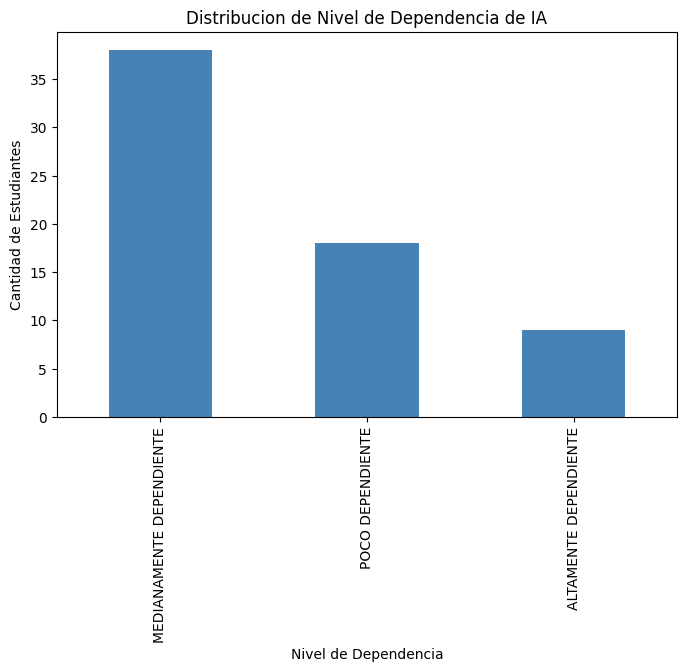

In [19]:
df["DEPENDENCIA_IA"].value_counts().plot(kind="bar", figsize=(8,5), color="steelblue")
plt.title("Distribucion de Nivel de Dependencia de IA")
plt.ylabel("Cantidad de Estudiantes")
plt.xlabel("Nivel de Dependencia")
plt.show()

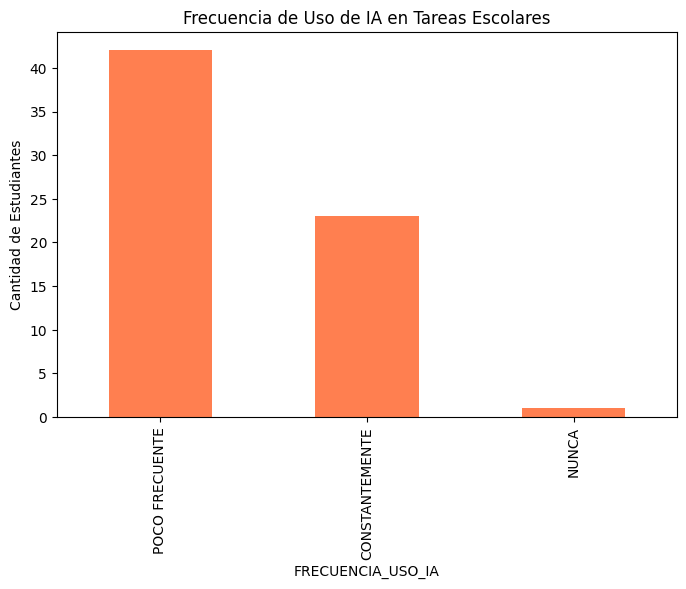

In [20]:
df["FRECUENCIA_USO_IA"].value_counts().plot(kind="bar", figsize=(8,5), color="coral")
plt.title("Frecuencia de Uso de IA en Tareas Escolares")
plt.ylabel("Cantidad de Estudiantes")
plt.show()

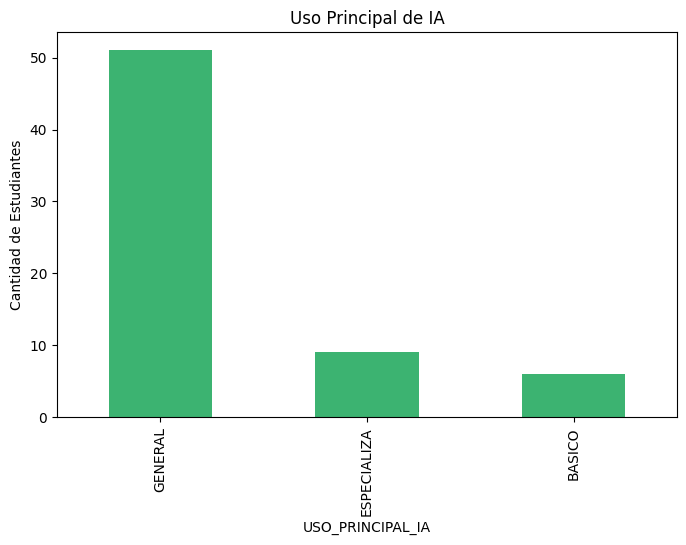

In [21]:
df["USO_PRINCIPAL_IA"].value_counts().plot(kind="bar", figsize=(8,5), color="mediumseagreen")
plt.title("Uso Principal de IA")
plt.ylabel("Cantidad de Estudiantes")
plt.show()

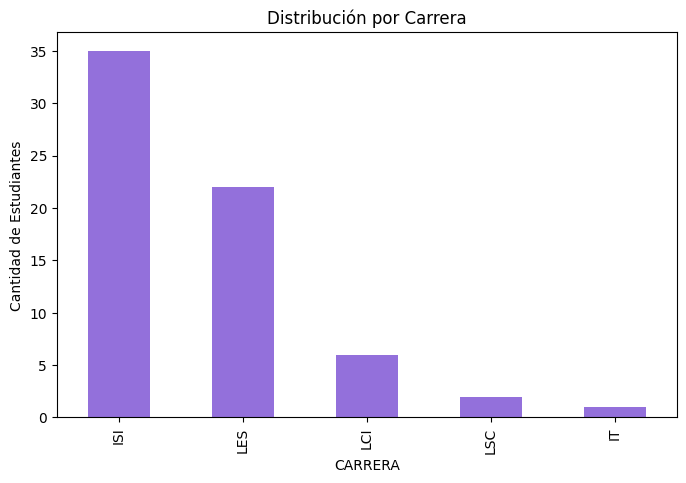

In [22]:
# Distribución por carrera
df["CARRERA"].value_counts().plot(kind="bar", figsize=(8,5), color="mediumpurple")
plt.title("Distribución por Carrera")
plt.ylabel("Cantidad de Estudiantes")
plt.show()

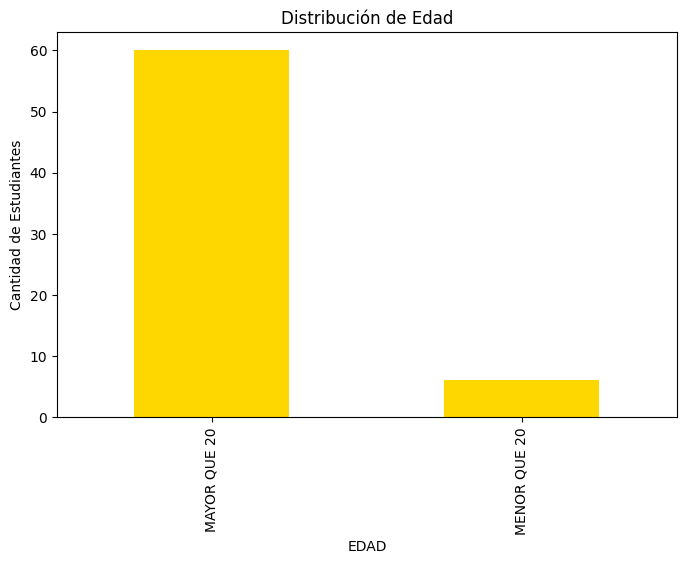

In [23]:
df["EDAD"].value_counts().sort_index().plot(kind="bar", figsize=(8,5), color="gold")
plt.title("Distribución de Edad")
plt.ylabel("Cantidad de Estudiantes")
plt.show()

In [24]:
#EDA ampliado
#BLOQUE 9.1. Frecuencia por mes


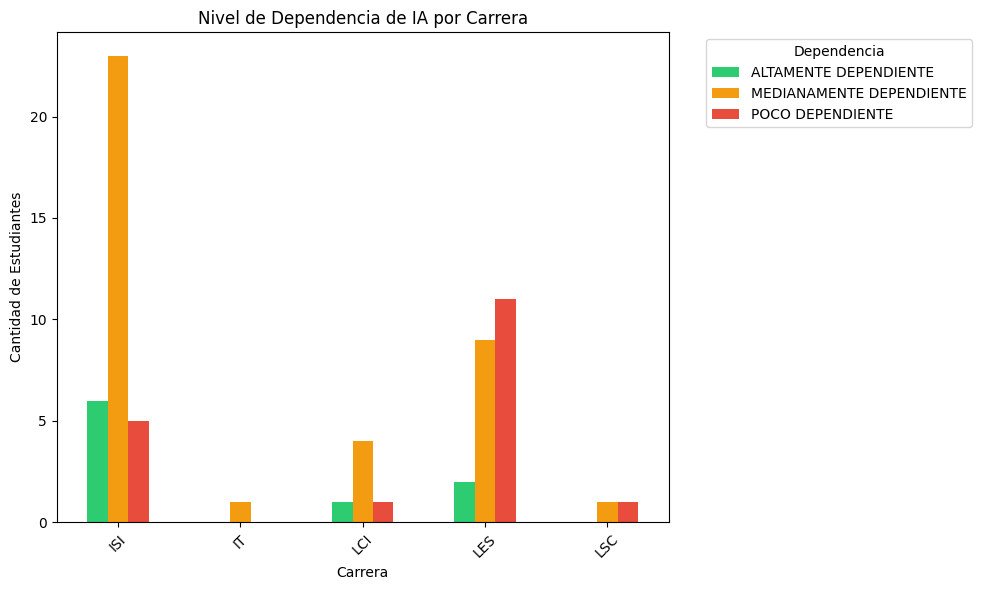

In [25]:
# DEPENDENCIA POR CARRERA
df_plot = df.copy()
dependencia_map = {
    "POCO DEPENDIENTE": 1,
    "MEDIANAMENTE DEPENDIENTE": 2,
    "ALTAMENTE DEPENDIENTE": 3,
    "DESCONOCIDO": 0
}
df_plot["DEPENDENCIA_IA"] = df["DEPENDENCIA_IA"].map(dependencia_map)

# Gráfico de barras agrupadas
carrera_dep = pd.crosstab(df["CARRERA"], df["DEPENDENCIA_IA"])

carrera_dep.plot(kind="bar", figsize=(10,6), color=["#2ecc71", "#f39c12", "#e74c3c"])
plt.title("Nivel de Dependencia de IA por Carrera")
plt.ylabel("Cantidad de Estudiantes")
plt.xlabel("Carrera")
plt.xticks(rotation=45)
plt.legend(title="Dependencia", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()


Tabla Cruzada: Frecuencia vs Dependencia
DEPENDENCIA_IA     ALTAMENTE DEPENDIENTE  MEDIANAMENTE DEPENDIENTE  \
FRECUENCIA_USO_IA                                                    
CONSTANTEMENTE                         6                        17   
NUNCA                                  0                         0   
POCO FRECUENTE                         3                        21   

DEPENDENCIA_IA     POCO DEPENDIENTE  
FRECUENCIA_USO_IA                    
CONSTANTEMENTE                    0  
NUNCA                             1  
POCO FRECUENTE                   17  


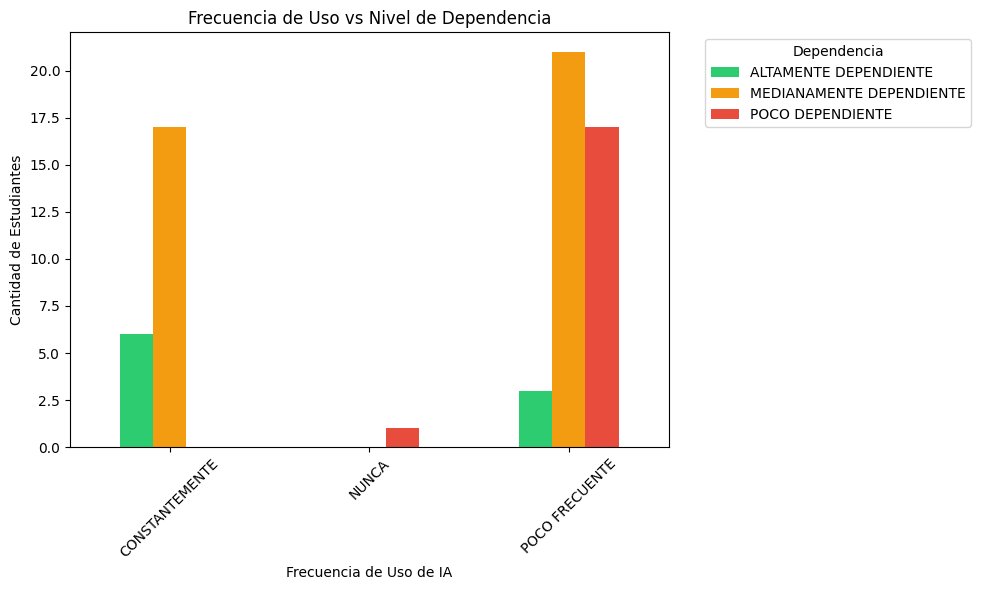

In [26]:
# FRECUENCIA vs DEPENDENCIA
confusión = pd.crosstab(df["FRECUENCIA_USO_IA"], df["DEPENDENCIA_IA"])

print("\nTabla Cruzada: Frecuencia vs Dependencia")
print(confusión)

# Gráfico de barras apiladas
confusión.plot(kind="bar", stacked=False, figsize=(10,6), 
               color=["#2ecc71", "#f39c12", "#e74c3c"])
plt.title("Frecuencia de Uso vs Nivel de Dependencia")
plt.ylabel("Cantidad de Estudiantes")
plt.xlabel("Frecuencia de Uso de IA")
plt.xticks(rotation=45)
plt.legend(title="Dependencia", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

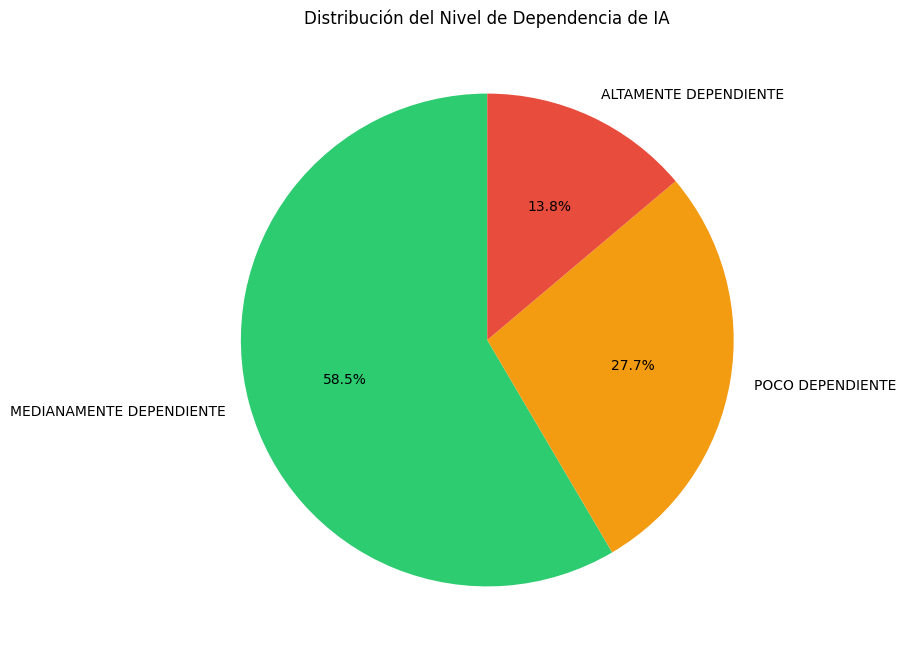

In [27]:
# DISTRIBUCIÓN DE DEPENDENCIA 
dep_counts = df["DEPENDENCIA_IA"].value_counts()

plt.figure(figsize=(8,8))
plt.pie(dep_counts.values, labels=dep_counts.index, autopct='%1.1f%%', 
        colors=["#2ecc71", "#f39c12", "#e74c3c"], startangle=90)
plt.title("Distribución del Nivel de Dependencia de IA")
plt.show()

Tabla Cruzada: Carrera vs Frecuencia de Uso
FRECUENCIA_USO_IA  CONSTANTEMENTE  NUNCA  POCO FRECUENTE
CARRERA                                                 
ISI                            16      0              19
IT                              0      0               1
LCI                             2      0               4
LES                             5      1              16
LSC                             0      0               2


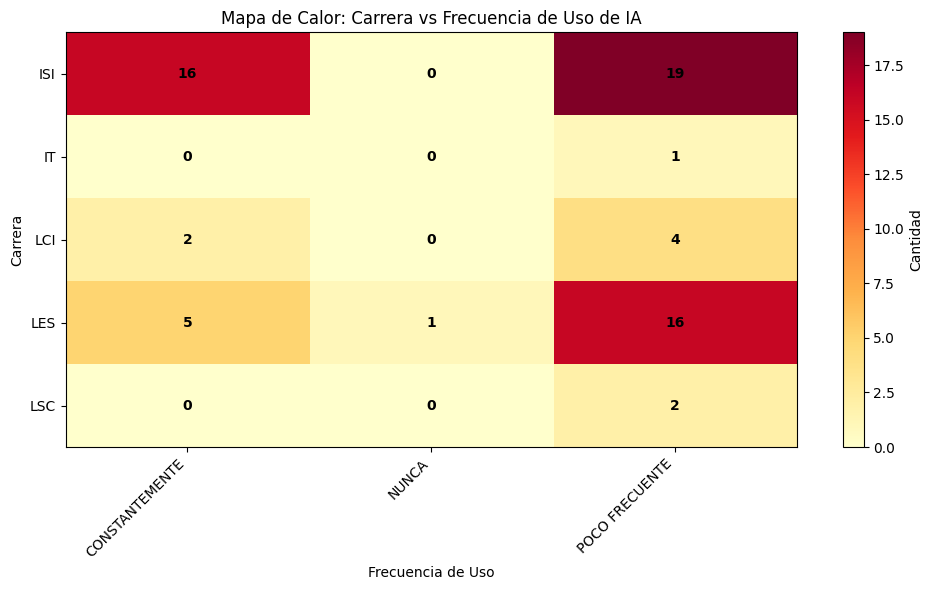

In [28]:
# BLOQUE 9.7. Mapa de calor: Carrera vs Frecuencia de Uso
# Verificar que los campos existan
if "CARRERA" in df.columns and "FRECUENCIA_USO_IA" in df.columns:
    
    tabla_carrera_frecuencia = pd.crosstab(
        df["CARRERA"],
        df["FRECUENCIA_USO_IA"]
    )
    
    print("Tabla Cruzada: Carrera vs Frecuencia de Uso")
    print(tabla_carrera_frecuencia)
    
    # Mapa de calor sin seaborn usando matplotlib
    plt.figure(figsize=(10, 6))
    plt.imshow(tabla_carrera_frecuencia, cmap="YlOrRd", aspect="auto")
    plt.colorbar(label="Cantidad")
    
    plt.xticks(range(len(tabla_carrera_frecuencia.columns)), 
               tabla_carrera_frecuencia.columns, rotation=45, ha='right')
    plt.yticks(range(len(tabla_carrera_frecuencia.index)), 
               tabla_carrera_frecuencia.index)
    
    # Agregar valores en las celdas
    for i in range(len(tabla_carrera_frecuencia.index)):
        for j in range(len(tabla_carrera_frecuencia.columns)):
            valor = tabla_carrera_frecuencia.iloc[i, j]
            plt.text(j, i, str(valor), ha='center', va='center', color='black', fontsize=10, fontweight='bold')
    
    plt.title("Mapa de Calor: Carrera vs Frecuencia de Uso de IA")
    plt.ylabel("Carrera")
    plt.xlabel("Frecuencia de Uso")
    plt.tight_layout()
    plt.show()
else:
    print("Las columnas CARRERA o FRECUENCIA_USO_IA no existen en el dataframe")

In [ ]:
#BLOQUE 10. Separar train y test
#Usaremos primero el modelo operativo

# =========================================
# BLOQUE 10: TRAIN / TEST SPLIT
# =========================================

In [ ]:
#BLOQUE 11. Definir variables categóricas y numéricas + pipeline
#Este bloque prepara el preprocesamiento correcto
# =========================================
# BLOQUE 11: PREPROCESAMIENTO PARA MODELOS
# =========================================

In [ ]:
# =========================================
# BLOQUE 11.1: FUNCIÓN GENERAL DE EVALUACIÓN
# =========================================

In [ ]:
#BLOQUE 12. Entrenar Árbol de Decisión
#Primer modelo de clasificación

# # =========================================
# BLOQUE 12: ÁRBOL DE DECISIÓN
# =========================================

In [ ]:
#BLOQUE 12.1. Matriz de confusión del árbol

In [ ]:
#BLOQUE 12.2. Ver probabilidades del árbol
#Esto ayuda mucho para interpretar confianza del modelo

In [ ]:

#BLOQUE 12.3. Casos que el árbol ve con mayor riesgo de consumación


In [ ]:

#BLOQUE 13. Visualizar el árbol
#Para interpretar las reglas del modelo


# =========================================
# BLOQUE 13: VISUALIZAR EL ÁRBOL
# =========================================

In [ ]:
#BLOQUE 13.1. Importancia de variables del árbol


In [ ]:
# =========================================
# BLOQUE 14: RANDOM FOREST
# =========================================

In [ ]:
#BLOQUE 14.1. Casos con mayor probabilidad según Random Forest

In [ ]:
#BLOQUE 15. Importancia de variables del Random Forest
